# SLAP2 session 2025-12-16 — soma check and example traces

Same animal (`sub-829704`) as `explore_slap2_control-blocks.ipynb`, recorded two
days earlier. The oddball block is a **sequence mismatch** rather than a
duration mismatch, and the first control block may differ too.

This notebook only repeats two things from that analysis:

1. Whole-session ΔF/F for ten example ROIs, green and red, with the blocks
   marked.
2. The soma check: does ROI 0 again sit above the other ROIs in red/green
   brightness of the mean images?

In [1]:
%load_ext autoreload
%autoreload 2

import warnings

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import ndimage

import sys
sys.path.append('..')
import utils

In [ ]:
path = ('../../data/slap2/sub-829704/'
        'sub-829704_ses-829704-2025-12-16-11-03-04_image+ophys.nwb')
stream = utils.open_local(path)

print(f'modality   : {stream.modality}')
print(f'session    : {stream.nwb.session_id}')
print(f'subject    : {stream.nwb.subject.subject_id}, {stream.nwb.subject.sex}, {stream.nwb.subject.age}')
print(f'DMDs       : {stream.dmds()}')
print(f'stim tables: {stream.stim_tables()}')

for dmd in stream.dmds():
    plane = stream.nwb.imaging_planes[f'ImagingPlane_{dmd}']
    print(f'{dmd}: {plane.location}, {plane.indicator}, '
          f'{plane.imaging_rate:.1f} Hz nominal, {len(stream.slap2_rois(dmd))} ROIs')

/tmp/nwbprobe/hdmf/spec/catalog.py:101: UserWarning: ndx-events defines a different specification for TimestampVectorData than the existing definition from nwb.event.yaml. Defaulting to the existing specification from nwb.event.yaml, but compatibility issues may be present. Please update the extension version if possible.
  self.register_spec(spec, source_file)
/tmp/nwbprobe/hdmf/spec/catalog.py:101: UserWarning: ndx-events defines a different specification for DurationVectorData than the existing definition from nwb.event.yaml. Defaulting to the existing specification from nwb.event.yaml, but compatibility issues may be present. Please update the extension version if possible.
  self.register_spec(spec, source_file)
/tmp/nwbprobe/hdmf/spec/catalog.py:101: UserWarning: ndx-events defines a different specification for MeaningsTable than the existing definition from table.yaml. Defaulting to the existing specification from table.yaml, but compatibility issues may be present. Please updat

modality   : slap2
session    : 829704_2025-12-16_11-03-04
subject    : 829704, M, P234D
DMDs       : ['DMD1', 'DMD2']
stim tables: ['jitter_control', 'movie', 'open_loop_prerecorded', 'rf_mapping', 'sequential_control_block', 'sequential_oddball', 'standard_control']
DMD1: VISp, iGluSnFR4f, RCaMP3, iGluSnFR4f, 123.5 Hz nominal, 65 ROIs
DMD2: VISp, iGluSnFR4f, RCaMP3, iGluSnFR4f, 93.5 Hz nominal, 79 ROIs


## Blocks

Group on `(BlockNumber, BlockLabel)` so the two standard-control repeats stay
separate. In the Dec 18 session the oddball table was `jitter_oddball`; here it
is `sequential_oddball`.

In [3]:
blocks = pd.DataFrame([
    {'block': int(bn), 'label': label, 'table': name, 'n_trials': len(g),
     'start': g.start_time.min(), 'stop': g.stop_time.max()}
    for name in stream.stim_tables()
    for (bn, label), g in stream.stim_df(name).groupby(['BlockNumber', 'BlockLabel'])
]).sort_values('block').reset_index(drop=True)

blocks['duration'] = blocks.stop - blocks.start
blocks['is_control'] = blocks.label.str.startswith('Control block')
blocks

,block,label,table,n_trials,start,stop,duration,is_control
0,1,Control block 1.1,standard_control,544,216.192992,596.688984,380.495992,True
1,2,Sequence mismatch block,sequential_oddball,6240,596.704000,2260.526992,1663.822992,False
2,3,Control block 1.2,standard_control,544,2260.885984,2641.375000,380.489016,True
3,4,Control block 2,sequential_control_block,1120,2641.386976,2940.006992,298.620016,True
4,5,Control block 3,jitter_control,368,2941.025984,3324.855992,383.830008,True
5,6,Control block 4,open_loop_prerecorded,11520,3324.878976,3719.093333,394.214357,True
6,7,Trippy,movie,2,3719.100000,4019.097984,299.997984,False
7,8,Zebra,movie,1,4019.094976,4319.094976,300.000000,False
8,9,RF mapping,rf_mapping,1215,4319.097984,4643.066992,323.969008,False


In [4]:
oddball = blocks[blocks.table.str.contains('oddball')].iloc[0]
std = blocks[blocks.table == 'standard_control']
print(f'oddball : {oddball.table} / {oddball.label}')
print(f'          {oddball.start:.1f} - {oddball.stop:.1f} s, {oddball.n_trials} trials')
for b in std.itertuples():
    print(f'{b.label}: {b.start:.1f} - {b.stop:.1f} s, {b.n_trials} trials, {b.duration:.0f} s')

oddball : sequential_oddball / Sequence mismatch block
          596.7 - 2260.5 s, 6240 trials
Control block 1.1: 216.2 - 596.7 s, 544 trials, 380 s
Control block 1.2: 2260.9 - 2641.4 s, 544 trials, 380 s


In [5]:
CONTROL_COLOURS = {
    'Control block 1.1': 'tab:blue',
    'Control block 1.2': 'tab:blue',
    'Control block 2':   'tab:purple',
    'Control block 3':   'tab:cyan',
    'Control block 4':   'tab:olive',
}


def shade_blocks(ax, blocks, colours=CONTROL_COLOURS, alpha=.13):
    for b in blocks.itertuples():
        if b.label in colours:
            ax.axvspan(b.start / 60, b.stop / 60, color=colours[b.label],
                       alpha=alpha, zorder=0)


def draw_timeline(ax, blocks, colours=CONTROL_COLOURS):
    for b in blocks.itertuples():
        ax.barh(0, b.duration / 60, left=b.start / 60, height=.6,
                color=colours.get(b.label, '.75'), edgecolor='w', lw=.6)
        ax.text((b.start + b.stop) / 120, 0, str(b.block), ha='center', va='center',
                fontsize=8, color='k')
    ax.set_yticks([])
    ax.set_ylim(-.45, .45)
    for side in ('left', 'right', 'top'):
        ax.spines[side].set_visible(False)

## Ten example ROIs, both channels

Decimated whole-session traces so both colour channels of 65 ROIs do not have
to sit in memory at full rate. Picks are spread along the field of view, and
ROI 0 is always included so it can be compared with the soma check below.

In [6]:
def load_dff_decimated(stream, dmd, channel, roi_idx, step=200, block=200_000):
    '''Whole-session ΔF/F for selected ROIs, block-averaged by `step` samples.'''
    rrs     = stream.nwb.processing['ophys'][f'Fluorescence_{dmd}'][f'{dmd}_dFF_{channel}']
    roi_idx = np.asarray(roi_idx)
    n       = rrs.data.shape[0]

    t_out, d_out = [], []
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)
        for a in range(0, n, block):
            m = ((min(a + block, n) - a) // step) * step
            if m == 0:
                continue
            chunk = rrs.data[a:a + m, :][:, roi_idx]
            t_out.append(rrs.timestamps[a:a + m].reshape(-1, step).mean(axis=1))
            d_out.append(np.nanmean(chunk.reshape(-1, step, len(roi_idx)), axis=1))

    return np.concatenate(t_out), np.concatenate(d_out).T

In [7]:
DMD  = 'DMD1'
rois = stream.slap2_rois(DMD)

along = np.argsort(rois.y.to_numpy())
roi_idx = np.sort(along[np.linspace(0, len(along) - 1, 10).astype(int)])
if 0 not in roi_idx:
    roi_idx = np.sort(np.unique(np.append(roi_idx, 0)))[:10]

print(f'{len(rois)} ROIs, plotting {list(roi_idx)}')
rois.loc[roi_idx, ['roi_id', 'n_pixels', 'x', 'y']]

65 ROIs, plotting [np.int64(0), np.int64(7), np.int64(18), np.int64(25), np.int64(32), np.int64(39), np.int64(46), np.int64(53), np.int64(61), np.int64(64)]


,roi_id,n_pixels,x,y
0,0,109,372.592717,56.721787
7,7,141,359.277999,83.897687
18,18,109,56.605291,154.126022
25,25,142,267.974046,222.973448
32,32,81,204.547133,272.928330
39,39,109,177.711031,326.267210
46,46,165,159.917397,354.828176
53,53,109,361.287072,461.941636
61,61,109,366.797985,574.028923
64,64,78,281.774620,128.667089


In [8]:
times, dff_green = load_dff_decimated(stream, DMD, 'green', roi_idx)
_,     dff_red   = load_dff_decimated(stream, DMD, 'red',   roi_idx)

print(f'{dff_green.shape[1]} points at {np.median(np.diff(times)):.2f} s spacing, '
      f'{times[0]:.0f}-{times[-1]:.0f} s')

3525 points at 1.00 s spacing, 20-3905 s


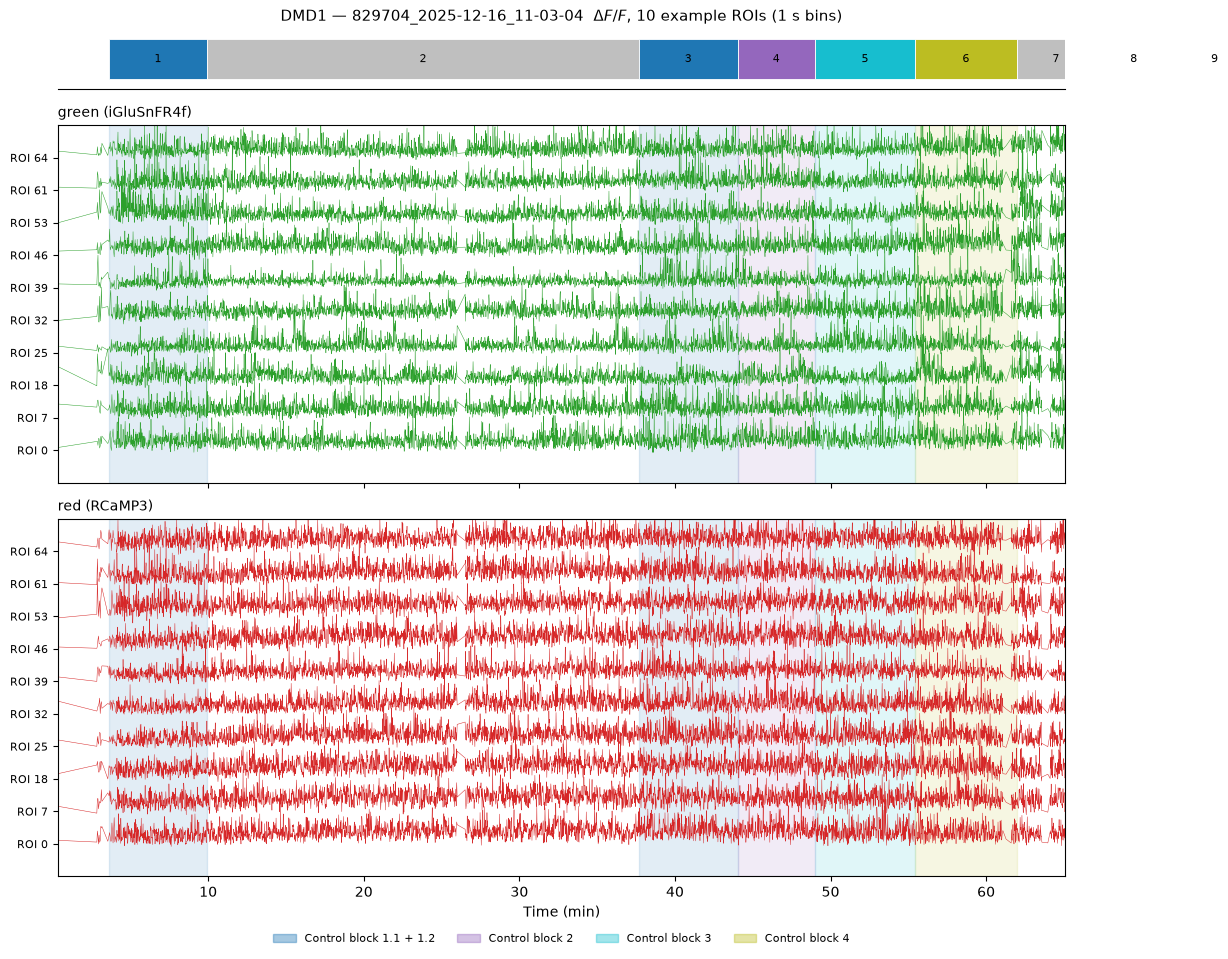

In [9]:
f = plt.figure(figsize=(13, 11))
gs = f.add_gridspec(3, 1, height_ratios=[.5, 3, 3], hspace=.14)

ax_tl = f.add_subplot(gs[0])
draw_timeline(ax_tl, blocks)
ax_tl.tick_params(labelbottom=False, bottom=False)
ax_tl.set_title(f'{DMD} — {stream.nwb.session_id}  $\\Delta F/F$, 10 example ROIs '
                f'({np.median(np.diff(times)):.0f} s bins)', fontsize=11)

axes = [f.add_subplot(gs[i + 1], sharex=ax_tl) for i in range(2)]
panels = [('green (iGluSnFR4f)', dff_green, 'tab:green'),
          ('red (RCaMP3)',       dff_red,   'tab:red')]

for ax, (label, arr, colour) in zip(axes, panels):
    for k, roi in enumerate(roi_idx):
        trace  = arr[k]
        lo, hi = np.nanpercentile(trace, [1, 99])
        ax.plot(times / 60, k + (trace - lo) / (hi - lo), lw=.35, color=colour)

    shade_blocks(ax, blocks)
    ax.set_yticks(np.arange(len(roi_idx)))
    ax.set_yticklabels([f'ROI {r}' for r in roi_idx], fontsize=8)
    ax.set_ylim(-1, len(roi_idx))
    ax.set_title(label, fontsize=10, loc='left')

axes[0].tick_params(labelbottom=False)

seen = {}
for b in blocks[blocks.is_control].itertuples():
    seen.setdefault(CONTROL_COLOURS[b.label], b.label.replace('.1', '.1 + 1.2'))
for colour, label in seen.items():
    axes[1].axvspan(np.nan, np.nan, color=colour, alpha=.4, label=label)
axes[1].legend(loc='upper center', bbox_to_anchor=(.5, -.13), ncol=4, fontsize=8,
               frameon=False)

axes[1].set_xlabel('Time (min)')
ax_tl.set_xlim(times[0] / 60, times[-1] / 60)
plt.show()

## Soma check: is ROI 0 again the red/green outlier?

Same metric as the Dec 18 notebook: mask-weighted brightness in the red mean
image divided by the same quantity in green. A soma filled with cytosolic
RCaMP3 should sit above a glutamate-sensor dendrite.

In [10]:
def roi_geometry(stream, dmd):
    '''Per-ROI support size, effective size and mean-image brightness.'''
    rois  = stream.slap2_rois(dmd)
    green = stream.slap2_mean_image(dmd, channel=0)
    red   = stream.slap2_mean_image(dmd, channel=1)

    out = []
    for row in rois.itertuples():
        m = row.pixel_mask
        x, y, w = m['x'].astype(float), m['y'].astype(float), m['weight'].astype(float)
        cx, cy = (x * w).sum(), (y * w).sum()
        yi, xi = m['y'].astype(int), m['x'].astype(int)
        g = float(np.nansum(green[yi, xi] * w))
        r = float(np.nansum(red[yi, xi] * w))
        out.append({
            'dmd':            dmd,
            'roi':            row.Index,
            'support_px':     row.n_pixels,
            'effective_px':   1. / np.sum(w ** 2),
            'x':              cx,
            'y':              cy,
            'green':          g,
            'red':            r,
            'red_over_green': r / g if g > 0 else np.nan,
        })
    return pd.DataFrame(out)

geom = pd.concat([roi_geometry(stream, d) for d in stream.dmds()], ignore_index=True)
geom.groupby('dmd')[['support_px', 'effective_px', 'red_over_green']].describe().T

dmd                         DMD1        DMD2
support_px     count   65.000000   79.000000
               mean   131.738462  123.430380
               std     49.837008   45.499700
               min     53.000000   71.000000
               25%    108.000000  102.000000
               50%    109.000000  109.000000
               75%    163.000000  123.000000
               max    263.000000  267.000000
effective_px   count   65.000000   79.000000
               mean    28.822363   28.268660
               std      2.539192    2.324539
               min     20.010440   21.125195
               25%     28.267414   27.495091
               50%     29.713895   28.790616
               75%     30.293695   30.041709
               max     31.317929   31.431621
red_over_green count   65.000000   79.000000
               mean     0.247904    0.261786
               std      0.100334    0.077252
               min      0.123376    0.161879
               25%      0.175866    0.206244
               50%      0.221370    0.244549
               75%      0.291538    0.291577
               max      0.617199    0.497536

In [11]:
print('ROI 0 vs the rest, red/green of the mean images')
print()
for dmd, sub in geom.groupby('dmd'):
    sub = sub.sort_values('roi')
    r0 = sub.loc[sub.roi == 0, 'red_over_green'].iloc[0]
    med = sub.red_over_green.median()
    rank = int((sub.red_over_green > r0).sum()) + 1
    top = sub.sort_values('red_over_green', ascending=False).iloc[0]
    print(f'{dmd}: ROI 0 r/g = {r0:.3f}  (median {med:.3f}, rank {rank}/{len(sub)})')
    print(f'      max is ROI {int(top.roi)} at {top.red_over_green:.3f}')
    print()

ROI 0 vs the rest, red/green of the mean images

DMD1: ROI 0 r/g = 0.179  (median 0.221, rank 48/65)
      max is ROI 33 at 0.617

DMD2: ROI 0 r/g = 0.256  (median 0.245, rank 36/79)
      max is ROI 22 at 0.498



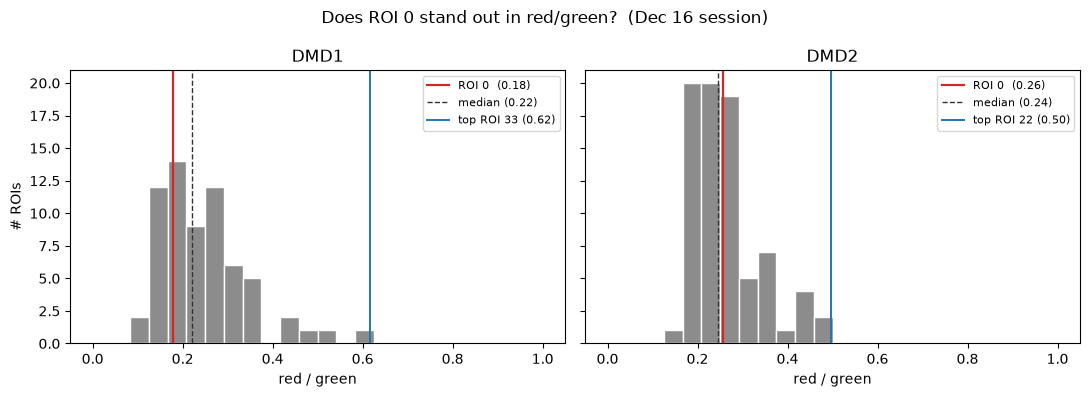

In [12]:
f, axs = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, dmd in zip(axs, stream.dmds()):
    sub = geom[geom.dmd == dmd]
    ax.hist(sub.red_over_green, bins=np.linspace(0, max(1.0, sub.red_over_green.max() + .05), 25),
            color='.55', edgecolor='w')
    r0 = sub.loc[sub.roi == 0, 'red_over_green'].iloc[0]
    top = sub.loc[sub.red_over_green.idxmax()]
    ax.axvline(r0, color='tab:red', lw=1.6, label=f'ROI 0  ({r0:.2f})')
    ax.axvline(sub.red_over_green.median(), color='.2', ls='--', lw=1,
               label=f'median ({sub.red_over_green.median():.2f})')
    ax.axvline(top.red_over_green, color='tab:blue', lw=1.4,
               label=f'top ROI {int(top.roi)} ({top.red_over_green:.2f})')
    ax.set_title(dmd)
    ax.set_xlabel('red / green')
    ax.legend(fontsize=8)
axs[0].set_ylabel('# ROIs')
f.suptitle('Does ROI 0 stand out in red/green?  (Dec 16 session)')
f.tight_layout()

ROI 0 is **not** the outlier in this session: on DMD1 it is below the median
(rank 48 of 65). Put it, and the actual top ROI, in the field of view so the
morphology can be compared with the Dec 18 case.

In [13]:
CAND_DMD = DMD
sub = geom[geom.dmd == CAND_DMD]
CAND_ROI = int(sub.loc[sub.red_over_green.idxmax(), 'roi'])

cand_rois  = stream.slap2_rois(CAND_DMD)
green_full = stream.slap2_mean_image(CAND_DMD, channel=0)
red_full   = stream.slap2_mean_image(CAND_DMD, channel=1)

scanned, n_patch = ndimage.label(np.isfinite(green_full))
cand_rois = cand_rois.assign(
    patch=scanned[cand_rois.y.round().astype(int), cand_rois.x.round().astype(int)],
    red_over_green=sub.red_over_green.to_numpy())

print(f'{n_patch} scanned patches, {100 * np.isfinite(green_full).mean():.0f} % of FOV scanned')
print(f'ROI 0  patch {int(cand_rois.patch[0])}, '
      f'ROIs there: {cand_rois.index[cand_rois.patch == cand_rois.patch[0]].tolist()}')
print(f'ROI {CAND_ROI} patch {int(cand_rois.patch[CAND_ROI])}, '
      f'ROIs there: {cand_rois.index[cand_rois.patch == cand_rois.patch[CAND_ROI]].tolist()}')

8 scanned patches, 5 % of FOV scanned
ROI 0  patch 1, ROIs there: [0, 2, 3, 4, 6, 7]
ROI 33 patch 6, ROIs there: [32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]


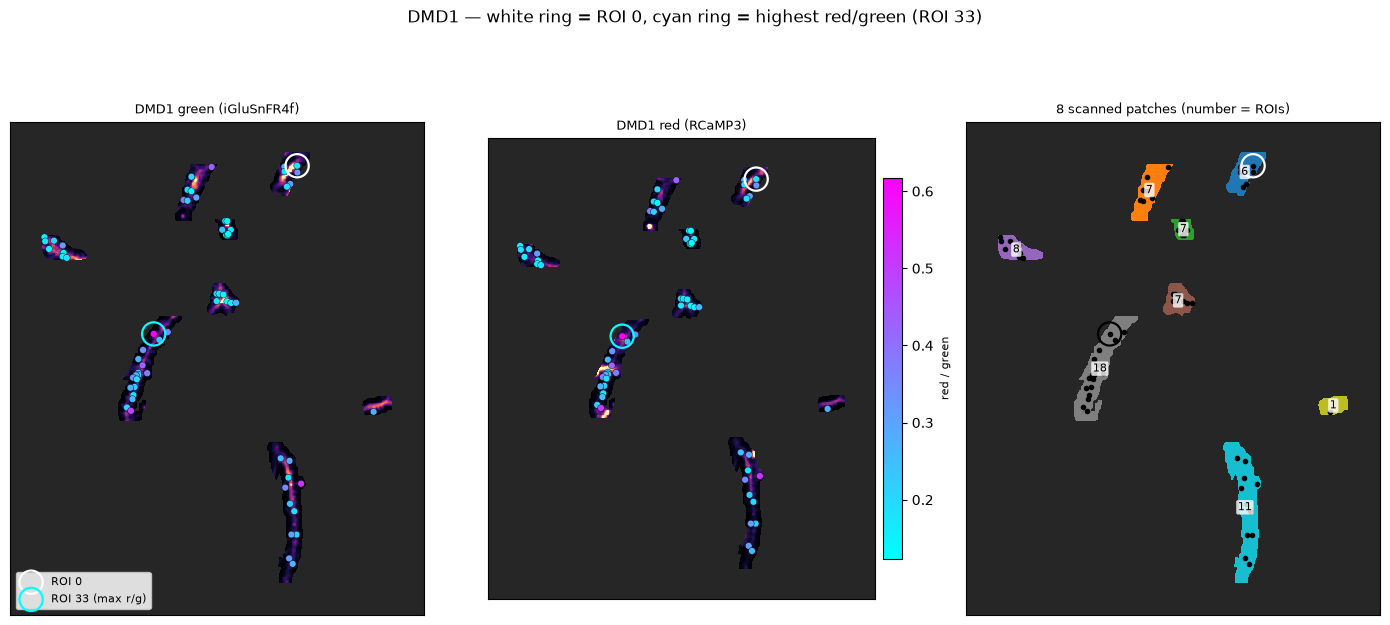

In [14]:
f, axs = plt.subplots(1, 3, figsize=(14, 7))

for ax, (label, img) in zip(axs[:2], [('green (iGluSnFR4f)', green_full),
                                      ('red (RCaMP3)', red_full)]):
    lo, hi = np.nanpercentile(img, [2, 99])
    ax.imshow(img, cmap='magma', vmin=lo, vmax=hi, interpolation='nearest')
    sc = ax.scatter(cand_rois.x, cand_rois.y, c=cand_rois.red_over_green, s=24,
                    cmap='cool', edgecolors='k', linewidths=.3)
    ax.scatter(cand_rois.x[0], cand_rois.y[0], s=280, facecolors='none',
               edgecolors='w', lw=1.6, label='ROI 0')
    ax.scatter(cand_rois.x[CAND_ROI], cand_rois.y[CAND_ROI], s=280, facecolors='none',
               edgecolors='cyan', lw=1.6, label=f'ROI {CAND_ROI} (max r/g)')
    ax.set_title(f'{CAND_DMD} {label}', fontsize=9)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_facecolor('.15')

axs[0].legend(loc='lower left', fontsize=8, framealpha=.85)
f.colorbar(sc, ax=axs[1], fraction=.046, pad=.02).set_label('red / green', fontsize=8)

axs[2].imshow(np.ma.masked_where(scanned == 0, scanned % 9), cmap='tab10',
              interpolation='nearest')
axs[2].scatter(cand_rois.x, cand_rois.y, s=9, color='k')
axs[2].scatter(cand_rois.x[0], cand_rois.y[0], s=280, facecolors='none',
               edgecolors='w', lw=1.6)
axs[2].scatter(cand_rois.x[CAND_ROI], cand_rois.y[CAND_ROI], s=280, facecolors='none',
               edgecolors='k', lw=1.6)
for p in np.unique(cand_rois.patch):
    ys, xs = np.where(scanned == p)
    n_here = int((cand_rois.patch == p).sum())
    axs[2].text(xs.mean(), ys.mean(), str(n_here), ha='center', va='center',
                fontsize=8, color='k',
                bbox=dict(boxstyle='round,pad=.15', fc='w', ec='none', alpha=.8))
axs[2].set_title(f'{n_patch} scanned patches (number = ROIs)', fontsize=9)
axs[2].set_xticks([]); axs[2].set_yticks([]); axs[2].set_facecolor('.15')

f.suptitle(f'{CAND_DMD} — white ring = ROI 0, cyan ring = highest red/green (ROI {CAND_ROI})',
           y=.99)
f.tight_layout()

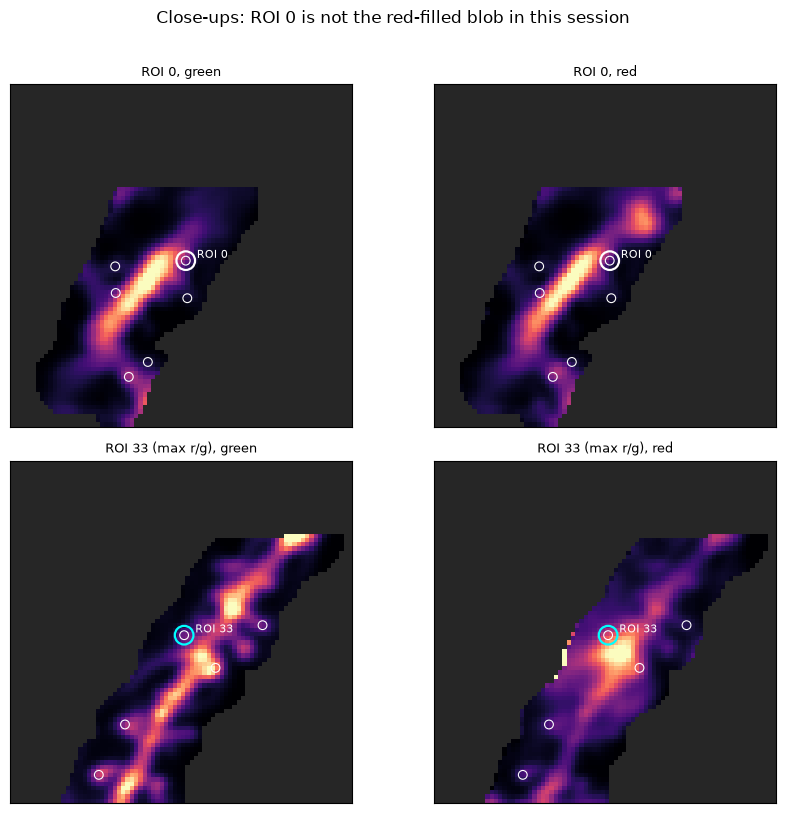

In [15]:
def crop_around(ax, img, roi, title, colour):
    pad = 40
    cy, cx = int(cand_rois.y[roi]), int(cand_rois.x[roi])
    y0, x0 = max(cy - pad, 0), max(cx - pad, 0)
    crop = img[y0:cy + pad, x0:cx + pad]
    lo, hi = np.nanpercentile(crop, [2, 99])
    ax.imshow(crop, cmap='magma', vmin=lo, vmax=hi, interpolation='nearest')
    near = cand_rois[cand_rois.x.between(x0, cx + pad) & cand_rois.y.between(y0, cy + pad)]
    ax.scatter(near.x - x0, near.y - y0, s=40, facecolors='none', edgecolors='w', lw=.8)
    ax.scatter(cand_rois.x[roi] - x0, cand_rois.y[roi] - y0, s=180,
               facecolors='none', edgecolors=colour, lw=1.6)
    ax.annotate(f'ROI {roi}', (cand_rois.x[roi] - x0, cand_rois.y[roi] - y0),
                color='w', fontsize=8, xytext=(8, 2), textcoords='offset points')
    ax.set_title(title, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_facecolor('.15')


f, axs = plt.subplots(2, 2, figsize=(9, 8))
crop_around(axs[0, 0], green_full, 0, 'ROI 0, green', 'w')
crop_around(axs[0, 1], red_full,   0, 'ROI 0, red', 'w')
crop_around(axs[1, 0], green_full, CAND_ROI, f'ROI {CAND_ROI} (max r/g), green', 'cyan')
crop_around(axs[1, 1], red_full,   CAND_ROI, f'ROI {CAND_ROI} (max r/g), red', 'cyan')
f.suptitle('Close-ups: ROI 0 is not the red-filled blob in this session', y=1.01)
f.tight_layout()

## Summary, compared with Dec 18

* **Oddball.** This session uses `sequential_oddball` (`Sequence mismatch
  block`, 6240 trials). Dec 18 used `jitter_oddball` (`Duration mismatch
  block`). The two standard-control repeats still bracket it as
  `Control block 1.1` then `1.2`, each 544 trials / 380 s.
* **ROI 0 is not a soma candidate here.** On DMD1 its red/green ratio is 0.18,
  below the median of 0.22 (rank 48 of 65). It shares a scanned patch with five
  other ROIs and does not look like a red-filled cell body.
* **The red/green outlier is DMD1 ROI 33** (0.62). Even that is a weaker
  outlier than Dec 18's ROI 0 (0.87), and it sits in a 18-ROI patch rather than
  in its own small one. ROI index 0 is not a stable soma label across days.